In [10]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 19 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

In [13]:
df=pd.read_excel("/content/태림_필터링데이터(찐).xlsx")

In [14]:
df.head()

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,May,2024,27,4.8,pc,FIRM,SEA,NaN,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,June,2024,3,4.8,pc,FIRM,SEA,NaN,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,June,2024,10,6.4,pc,FIRM,SEA,NaN,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,June,2024,26,6.4,pc,FORECAST,SEA,NaN,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,July,2024,4,6.4,pc,FORECAST,SEA,NaN,1.656.750


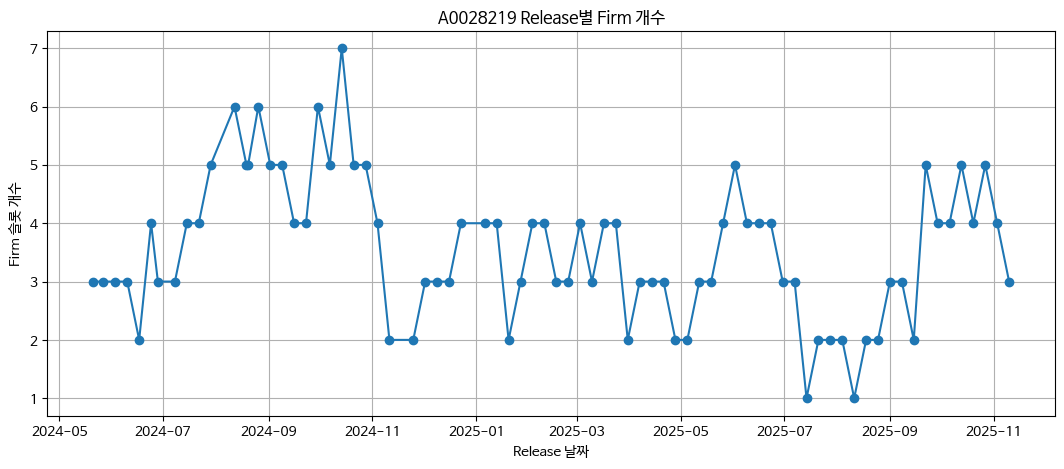

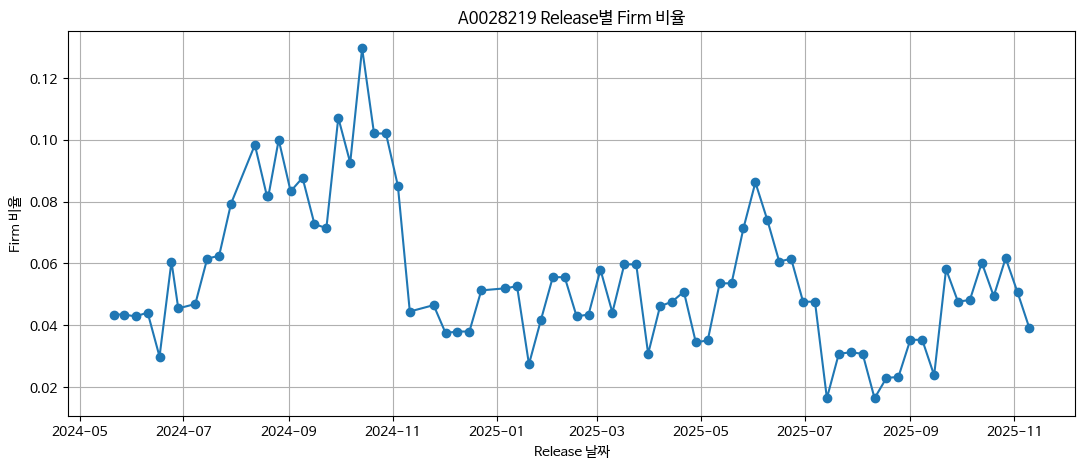

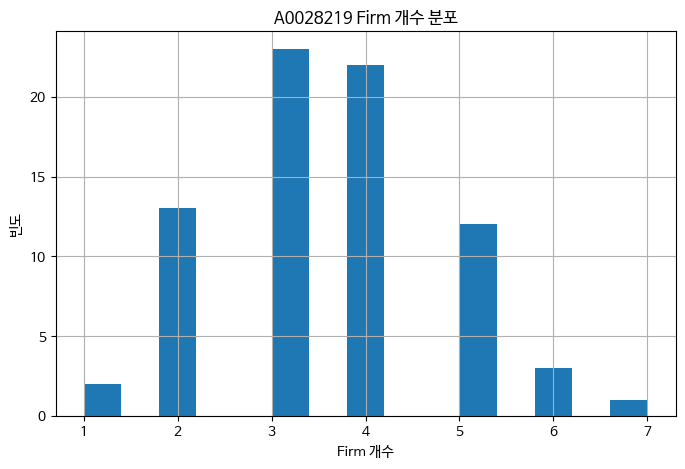

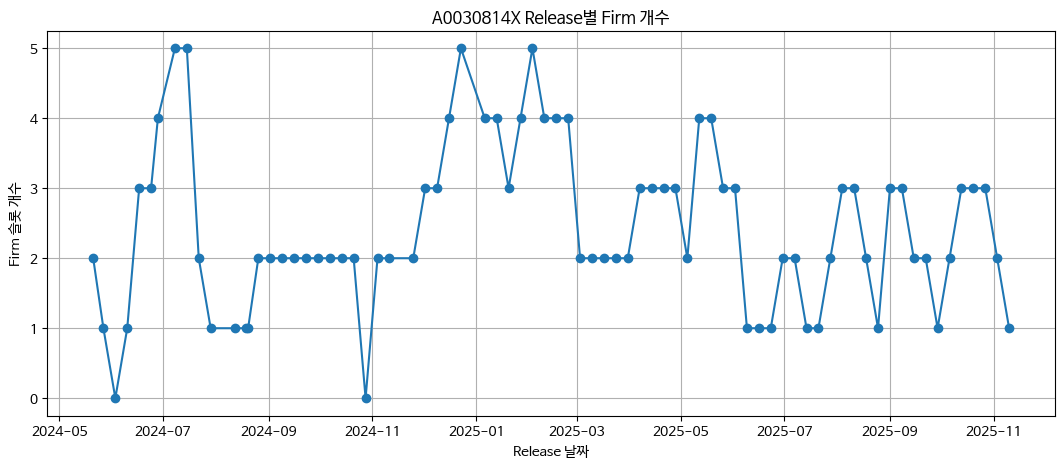

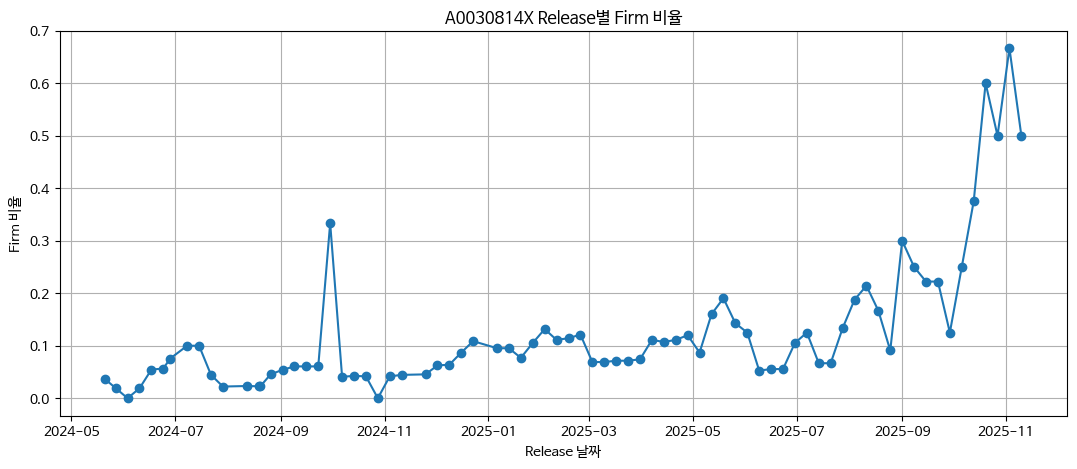

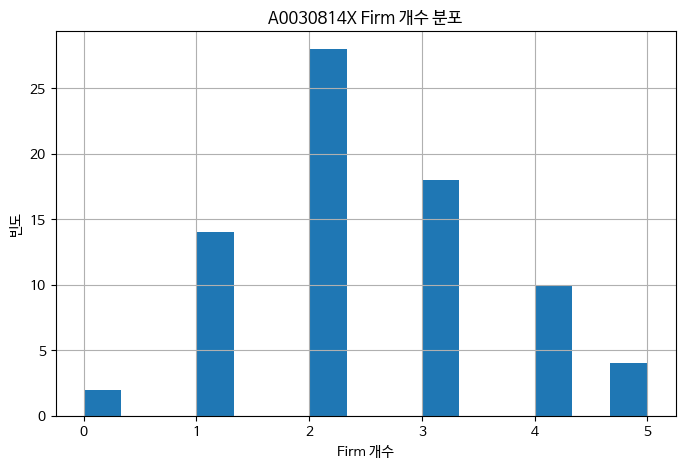

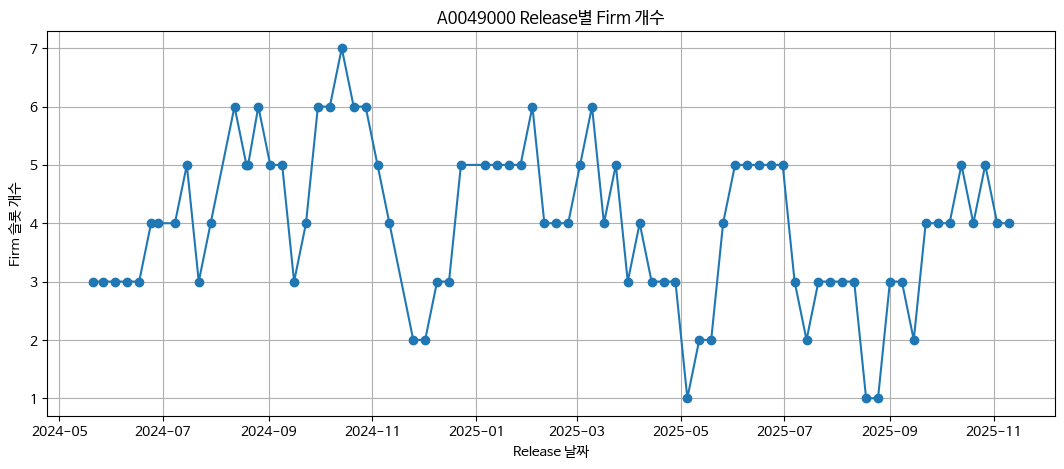

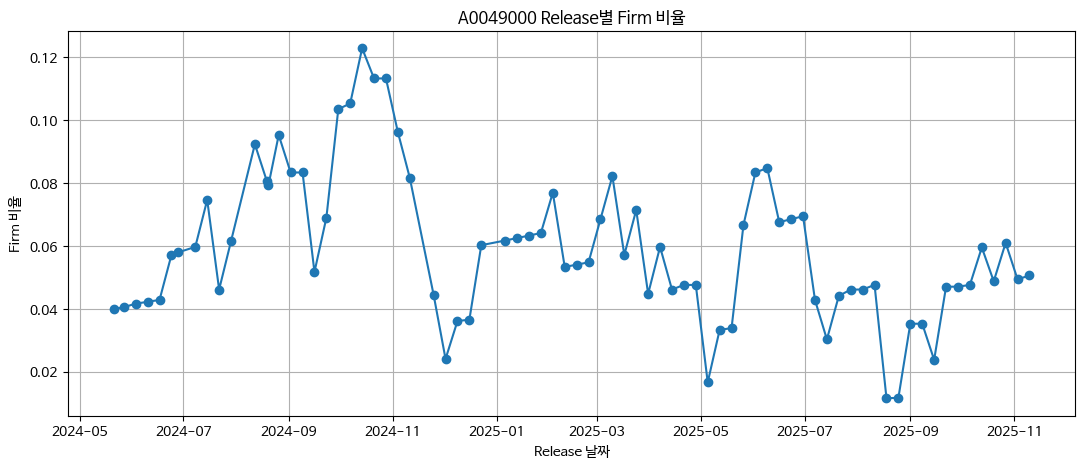

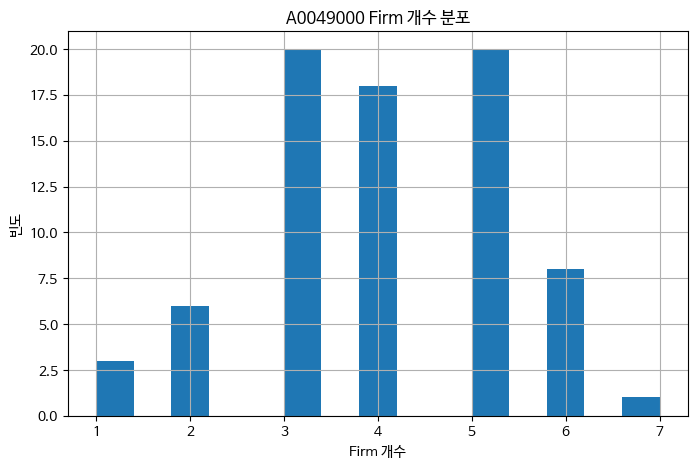

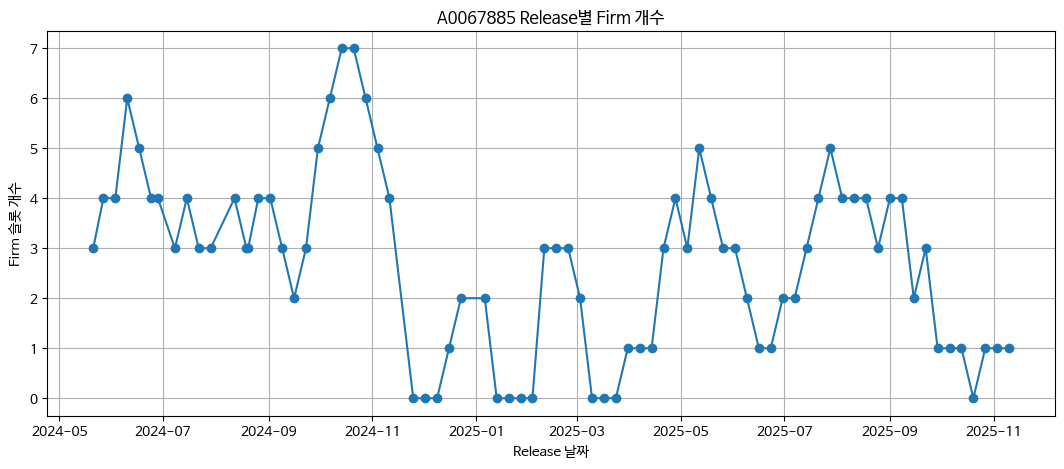

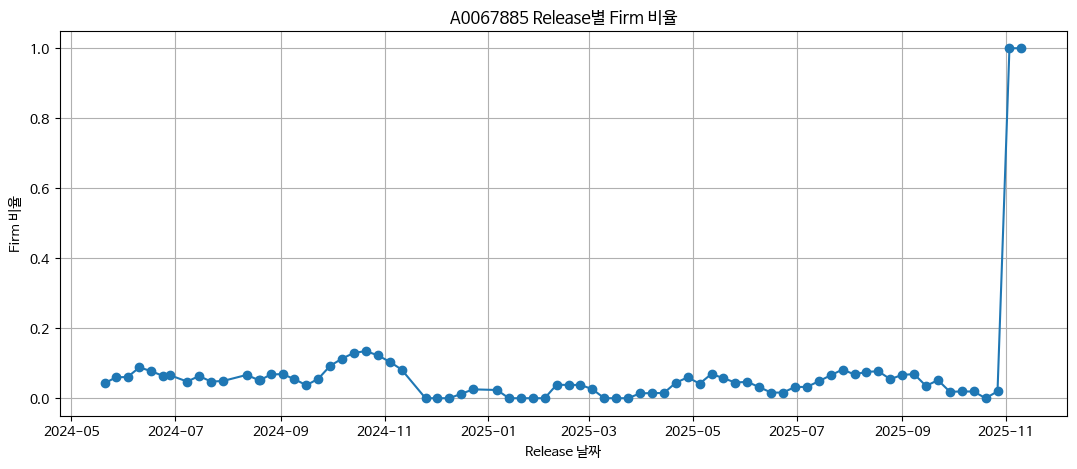

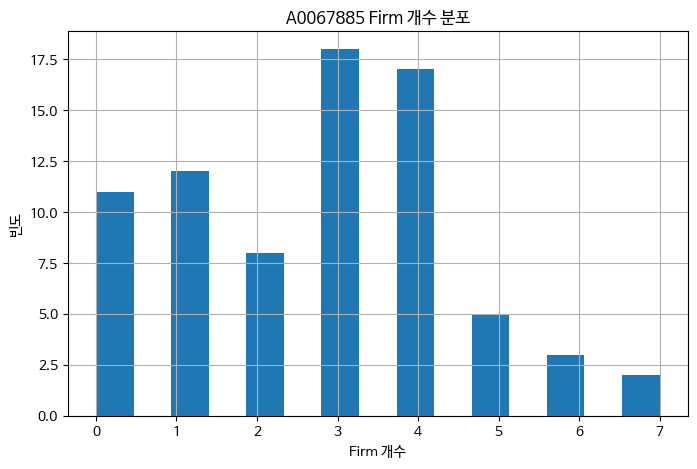

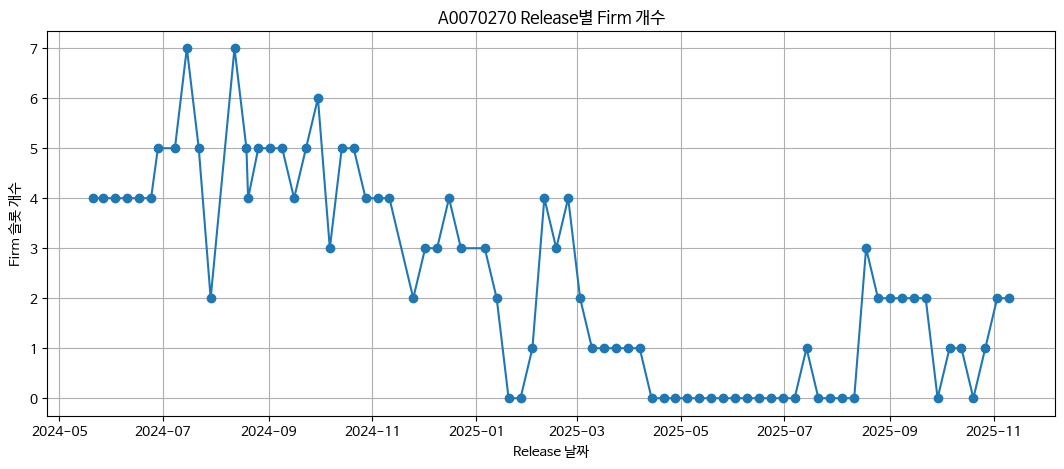

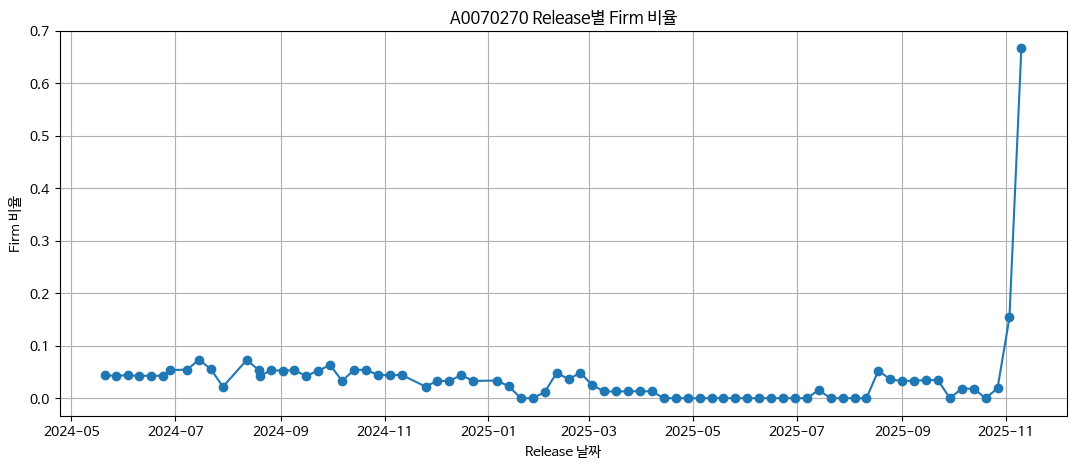

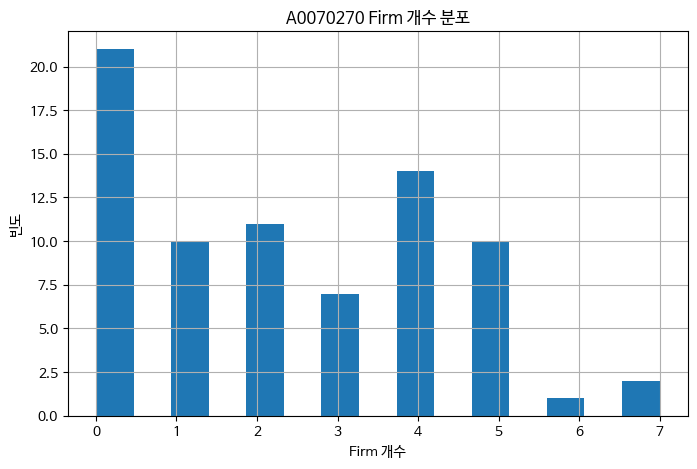

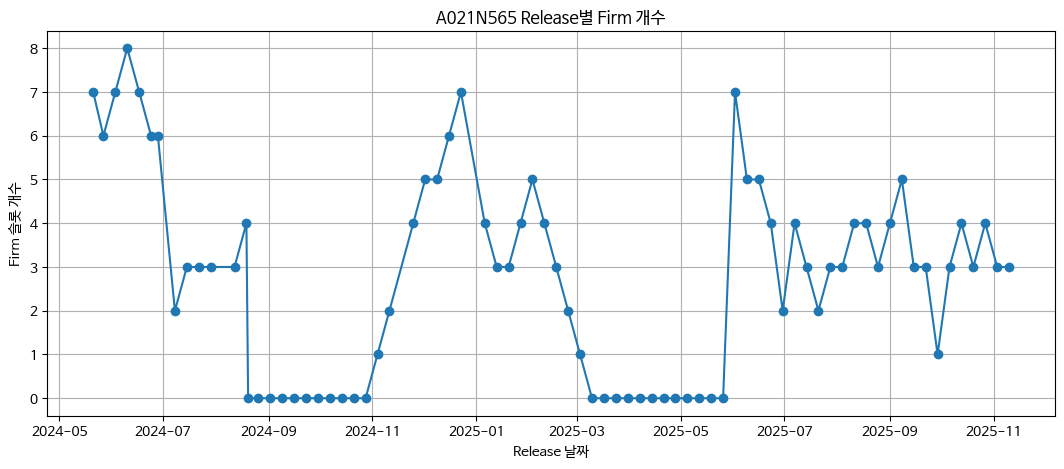

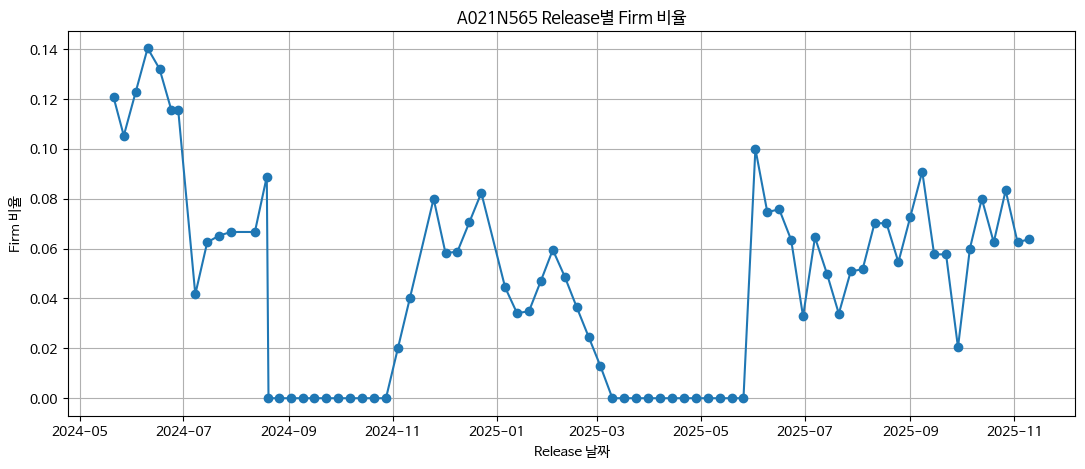

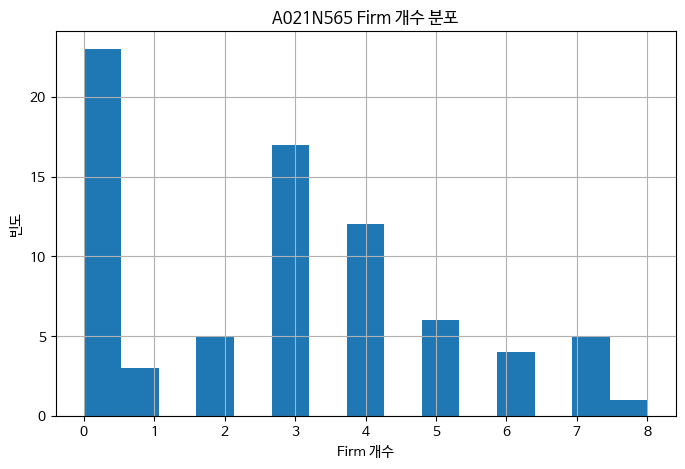

In [15]:

import matplotlib.font_manager as fm

# release 날짜 생성
df["release_date"] = pd.to_datetime(df["ID_Release"].str[:8], format="%Y%m%d")

# 출하 예정일 생성
df["ship_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str)
)

# ship_slot 생성
df["ship_slot"] = df["ZF_PN"].astype(str) + "_" + df["ship_date"].astype(str)

# firm 여부
df["is_firm"] = (df["Firm/Forecast"] == "FIRM").astype(int)

products = df["ZF_PN"].unique()

for pn in products:

    temp = df[df["ZF_PN"] == pn].copy()
    temp = temp.sort_values("release_date")

    temp = temp.drop_duplicates(["release_date","ship_slot"], keep="last")

    firm_count = temp.groupby("release_date")["is_firm"].sum()
    total_count = temp.groupby("release_date")["ship_slot"].count()
    firm_ratio = firm_count / total_count

    # ================================
    # ⭐ 그래프1 Firm 개수
    # ================================
    plt.figure(figsize=(13,5))
    plt.plot(firm_count.index, firm_count.values, marker='o')
    plt.title(f"{pn} Release별 Firm 개수")
    plt.xlabel("Release 날짜")
    plt.ylabel("Firm 슬롯 개수")
    plt.grid()
    plt.show()

    # ================================
    # ⭐ 그래프2 Firm 비율
    # ================================
    plt.figure(figsize=(13,5))
    plt.plot(firm_ratio.index, firm_ratio.values, marker='o')
    plt.title(f"{pn} Release별 Firm 비율")
    plt.xlabel("Release 날짜")
    plt.ylabel("Firm 비율")
    plt.grid()
    plt.show()

    # ================================
    # ⭐ 그래프3 Firm 개수 분포
    # ================================
    plt.figure(figsize=(8,5))
    plt.hist(firm_count.values, bins=15)
    plt.title(f"{pn} Firm 개수 분포")
    plt.xlabel("Firm 개수")
    plt.ylabel("빈도")
    plt.grid()
    plt.show()
